In [2]:
from os import listdir, makedirs
from os.path import isfile, isdir, join

import numpy as np
import pandas as pd

flare_file_path = './output/joined_flares.csv'
merged_sharp_path = '../new-data-loc/'
output_merged_sharp_path = '../annotated-new-data/'

noaa_map_path = './all_harps_with_noaa_ars.txt'
noaa_map = False  # global variable
downloads_noaa_map = False # global variable

from flare_reader import get_flare_dataframe
from aia_flare_integration import get_aia_flare_dataframe, get_goes_flare_dataframe
# fdf = get_flare_dataframe(flare_file_path)



In [5]:
goes_fl_file_path = './allFlares.txt'
goes_fl = get_goes_flare_dataframe(goes_fl_file_path)
# goes_fl[['goes_class', 'event_date']][(goes_fl['end_time'] <= goes_fl['peak_time'])]
goes_fl[(goes_fl['peak_time'] <= goes_fl['start_time'])]

,end_time,event_date,goes_class,goes_location,noaa_active_region,peak_time,start_time,id_goes
1621,2011-04-12 00:03:00,2011-04-11,C2.5,"(-25, 12)",11190,2011-04-11 00:00:00,2011-04-11 23:40:00,1622
3563,2012-04-06 00:05:00,2012-04-05,C1.1,"(0, 0)",11450,2012-04-05 00:00:00,2012-04-05 23:50:00,3564
3969,2012-06-07 00:05:00,2012-06-06,C1.0,"(6, -19)",11494,2012-06-06 00:00:00,2012-06-06 23:56:00,3970
3978,2012-06-07 13:46:00,2012-06-07,C1.1,"(0, 12)",11499,2012-06-07 13:40:00,2012-06-07 13:40:00,3979
4386,2012-07-31 00:04:00,2012-07-30,C6.3,"(0, 0)",11538,2012-07-30 00:00:00,2012-07-30 23:50:00,4387
4853,2012-10-14 00:18:00,2012-10-13,C1.5,"(-25, 11)",11589,2012-10-13 00:00:00,2012-10-13 23:46:00,4854
8364,2014-05-26 00:04:00,2014-05-25,C3.8,"(73, -17)",12065,2014-05-25 00:00:00,2014-05-25 23:49:00,8365
13184,2017-03-27 00:08:00,2017-03-26,C1.3,"(-33, 12)",12644,2017-03-26 00:00:00,2017-03-26 23:49:00,13185


In [155]:
def hasLocation(row):
    return row['goes_location'] != '(0, 0)'

def hasValidARNo(row):
    return row['noaa_active_region'] != 0

def get_stats(subset_df):
    total = subset_df.shape[0]
    no_loc_size = subset_df[~subset_df.apply(hasLocation, axis =1)].shape[0]
    with_loc_size = subset_df[subset_df.apply(hasLocation, axis =1)].shape[0]
    
    no_arno_df = subset_df[~subset_df.apply(hasValidARNo, axis =1)]
    with_arno_df = subset_df[subset_df.apply(hasValidARNo, axis =1)]
    no_ar_size = no_arno_df.shape[0]
    with_ar_size = with_arno_df.shape[0]
    
    if no_ar_size == 0:
        no_ar_loc_size = 0
    else:
        no_ar_loc_size = no_arno_df[~no_arno_df.apply(hasLocation, axis =1)].shape[0]
    with_ar_loc_size = with_arno_df[with_arno_df.apply(hasLocation, axis =1)].shape[0]
    
    return [total, with_ar_size, no_ar_size, with_loc_size, no_loc_size, with_ar_loc_size, no_ar_loc_size] 

def restructure_stats(listB, listC, listM, listX):
    Total = [listB[0], listC[0], listM[0], listX[0]]
    Valid_AR_No = [listB[1], listC[1], listM[1], listX[1]]
    Invalid_AR_No = [listB[2], listC[2], listM[2], listX[2]]
    Valid_Loc = [listB[3], listC[3], listM[3], listX[3]]
    Invalid_Loc = [listB[4], listC[4], listM[4], listX[4]]
    Valid_AR_No_Loc = [listB[5], listC[5], listM[5], listX[5]]
    Invalid_AR_No_Loc = [listB[6], listC[6], listM[6], listX[6]]

    raw_data = {'FL_Class': ['B-class', 'C-class', 'M-class', 'X-class'],
            'Total': Total,
            'Valid_AR_No': Valid_AR_No,
            'Invalid_AR_No': Invalid_AR_No,
            'Valid_Loc': Valid_Loc,
            'Invalid_Loc': Invalid_Loc,
            'Valid_AR_No_Loc': Valid_AR_No_Loc,
            'Invalid_AR_No_Loc': Invalid_AR_No_Loc
               }
    df = pd.DataFrame(raw_data, columns = ['FL_Class', 'Total', 'Valid_AR_No', 'Invalid_AR_No', 'Valid_Loc',
                                      'Invalid_Loc', 'Valid_AR_No_Loc', 'Invalid_AR_No_Loc'])
    return df

listB = get_stats(goes_fl[goes_fl['goes_class'].str.startswith('B')])
listC = get_stats(goes_fl[goes_fl['goes_class'].str.startswith('C')])
listM = get_stats(goes_fl[goes_fl['goes_class'].str.startswith('M')])
listX = get_stats(goes_fl[goes_fl['goes_class'].str.startswith('X')])

viz_df = restructure_stats(listB, listC, listM, listX)
viz_df

,FL_Class,Total,Valid_AR_No,Invalid_AR_No,Valid_Loc,Invalid_Loc,Valid_AR_No_Loc,Invalid_AR_No_Loc
0,B-class,5697,4326,1371,1126,4571,1095,1340
1,C-class,7757,6839,918,3412,4345,3381,887
2,M-class,743,710,33,401,342,401,33
3,X-class,50,50,0,33,17,33,0


In [30]:
def hasLocation(row):
    return row['goes_location'] != '(0, 0)'

def hasValidARNo(row):
    return row['noaa_active_region'] != 0

In [90]:
%matplotlib nbagg

import matplotlib.pyplot as plt


In [4]:
import numpy as np
np.nan > 250

False

<IPython.core.display.Javascript object>


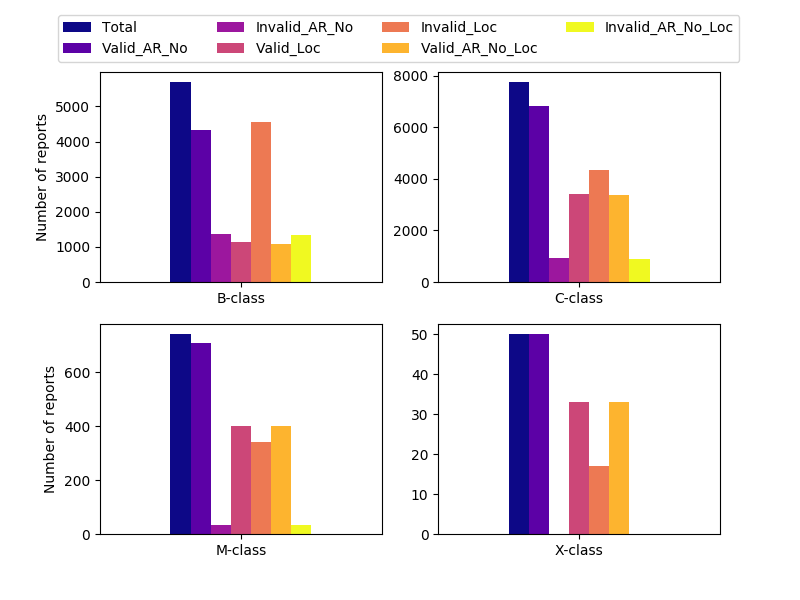

In [196]:

fig, axes = plt.subplots(nrows=2, ncols=2)

viz_df[viz_df["FL_Class"] == 'B-class'].plot(kind='bar', colormap='plasma', ax=axes[0,0])
viz_df[viz_df["FL_Class"] == 'C-class'].plot(kind='bar', colormap='plasma', ax=axes[0,1])
viz_df[viz_df["FL_Class"] == 'M-class'].plot(kind='bar', colormap='plasma', ax=axes[1,0])
viz_df[viz_df["FL_Class"] == 'X-class'].plot(kind='bar', colormap='plasma', ax=axes[1,1])
axes[0,0].set_xticklabels(["B-class"],  rotation='horizontal')
axes[0,1].set_xticklabels(["C-class"],  rotation='horizontal')
axes[1,0].set_xticklabels(["M-class"],  rotation='horizontal')
axes[1,1].set_xticklabels(["X-class"],  rotation='horizontal')

axes[0,0].set(ylabel='Number of reports')
axes[1,0].set(ylabel='Number of reports')

axes[0,0].legend_.remove()
axes[0,1].legend_.remove()
axes[1,1].legend_.remove()
axes[1,0].legend(bbox_to_anchor=(-0.15, 2.25), loc='lower left', borderaxespad=-0.0, ncol=4)
fig.set_size_inches(8, 6)
plt.savefig('./goes_flares_analytics.pdf',  bbox_inches='tight', dpi = 600)


# axes[0,0].legend_.remove()

# df2.plot(ax=axes[0,1])

# ax = viz_df[viz_df["FL_Class"] == 'B-class'].plot.bar()
# ax.set_xticklabels(viz_df['FL_Class'],  rotation='horizontal')

